# Sentiment Analysis Benchmark: Financial Text

**Objetivo:** Comparar abordagens progressivamente mais sofisticadas para classificação de sentimento em texto financeiro, desde representações clássicas (BoW, TF-IDF) até deep learning (rede neural com embeddings e FinBERT pré-treinado).

**Dataset:** [Financial PhraseBank](https://huggingface.co/datasets/financial_phrasebank) — ~5.000 frases de notícias financeiras anotadas por especialistas em três classes: positivo, negativo e neutro.

**Motivação:** Análise de sentimento é uma das aplicações mais diretas de NLP ao mercado financeiro. O sentimento agregado em notícias, relatórios e comunicados funciona como proxy para expectativas e posicionamento de mercado. Entender como diferentes representações textuais capturam (ou perdem) nuances semânticas é fundamental antes de aplicar essas técnicas a problemas reais.

---

### Estrutura

1. **Setup e Dados** — Carregamento, inspeção e análise exploratória
2. **Pré-processamento** — Pipelines de texto para cada abordagem
3. **Modelo 1: BoW + Logistic Regression** — Baseline mais simples
4. **Modelo 2: TF-IDF + Naive Bayes / Logistic Regression** — Ponderação por importância
5. **Modelo 3: Rede Neural com Embeddings** — Aprendendo representações densas
6. **Modelo 4: FinBERT** — Transformer pré-treinado para domínio financeiro
7. **Comparação e Análise de Erros** — Tabela comparativa, confusion matrices, análise qualitativa
8. **Conclusões** — O que cada nível de sofisticação compra em performance

---
## 1. Setup e Dados

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import pipeline as hf_pipeline

from datasets import load_dataset

# Configurações
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

/Users/matheus/projetos/analise_sentimento/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 Carregamento do Dataset

O Financial PhraseBank tem subsets por nível de concordância entre anotadores: `sentences_50agree`, `sentences_66agree`, `sentences_75agree` e `sentences_allagree`. Maior concordância = menos ambiguidade, mas menos dados. Vamos usar o subset de 75% como compromisso.

In [2]:
sentences = []
labels = []

with open('FinancialPhraseBank-v1.0/Sentences_75Agree.txt', encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        if '@' in line:
            sentence, label = line.rsplit('@', 1)
            sentences.append(sentence.strip())
            labels.append(label.strip())

df = pd.DataFrame({'sentence': sentences, 'label_text': labels})
df

,sentence,label_text
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive
...,...,...
3448,Operating result for the 12-month period decre...,negative
3449,HELSINKI Thomson Financial - Shares in Cargote...,negative
3450,LONDON MarketWatch -- Share prices ended lower...,negative
3451,Operating profit fell to EUR 35.4 mn from EUR ...,negative


In [3]:
label_map_inv = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['label_text'].map(label_map_inv)
df

,sentence,label_text,label
0,"According to Gran , the company has no plans t...",neutral,1
1,With the new production plant the company woul...,positive,2
2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,"In the third quarter of 2010 , net sales incre...",positive,2
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,2
...,...,...,...
3448,Operating result for the 12-month period decre...,negative,0
3449,HELSINKI Thomson Financial - Shares in Cargote...,negative,0
3450,LONDON MarketWatch -- Share prices ended lower...,negative,0
3451,Operating profit fell to EUR 35.4 mn from EUR ...,negative,0


In [4]:
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3453 entries, 0 to 3452
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   sentence    3453 non-null   str  
 1   label_text  3453 non-null   str  
 2   label       3453 non-null   int64
dtypes: int64(1), str(2)
memory usage: 527.1 KB


### 1.2 Análise Exploratória (EDA)

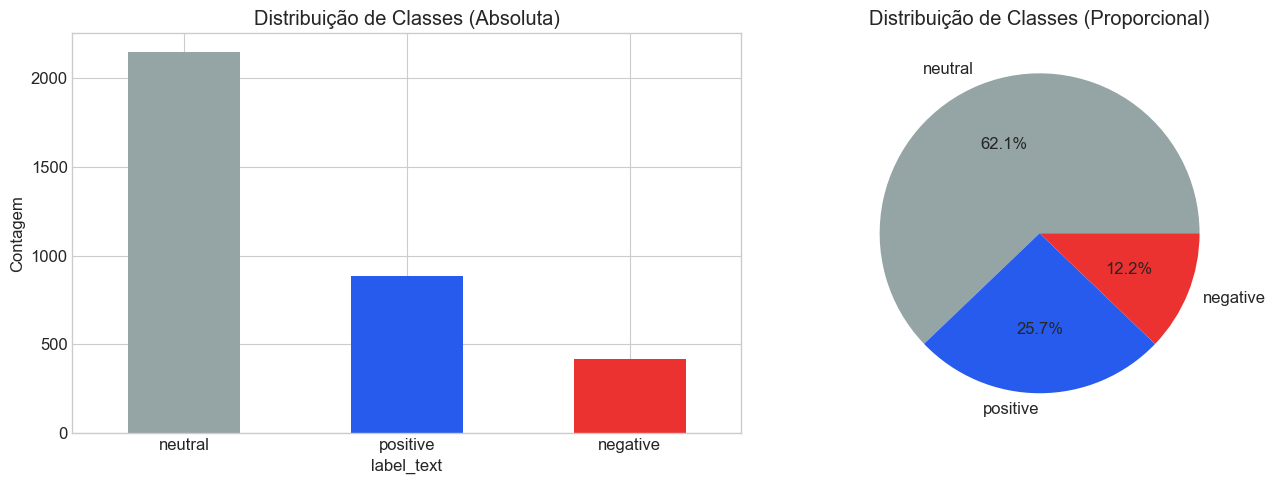

In [ ]:
# Distribuição de classes
# NOTA: Espera-se desbalanceamento —> maioria das frases financeiras são neutras (reportando fatos).
# Isso tem implicações diretas na escolha de métricas (F1-macro > accuracy).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem absoluta
df['label_text'].value_counts().plot(kind='bar', ax=axes[0], color=["#95a5a6", "#265bed", "#ec3131"])
axes[0].set_title('Distribuição de Classes (Absoluta)')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=0)

# Proporção
df['label_text'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=["#95a5a6", "#265bed", "#ec3131"]
)
axes[1].set_title('Distribuição de Classes (Proporcional)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

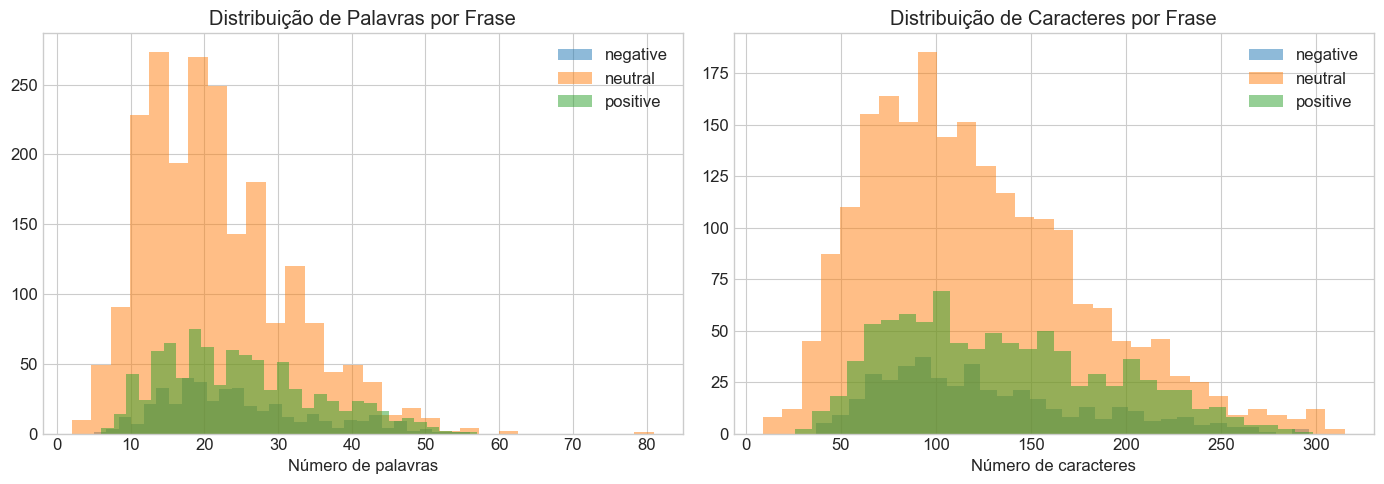

             count  mean   std  min   25%   50%   75%   max
label_text                                                 
negative     420.0  24.5  10.1  5.0  17.0  22.0  30.0  56.0
neutral     2146.0  21.5   9.8  2.0  14.0  20.0  27.0  81.0
positive     887.0  24.9  10.3  6.0  17.0  23.0  31.0  57.0


In [ ]:
# Distribuição de comprimento das frases por classe

df['word_count'] = df['sentence'].apply(lambda x: len(x.split()))
df['char_count'] = df['sentence'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in ['negative', 'neutral', 'positive']:
    subset = df[df['label_text'] == label]
    axes[0].hist(subset['word_count'], bins=30, alpha=0.5, label=label)
    axes[1].hist(subset['char_count'], bins=30, alpha=0.5, label=label)

axes[0].set_title('Distribuição de Palavras por Frase')
axes[0].set_xlabel('Número de palavras')
axes[0].legend()

axes[1].set_title('Distribuição de Caracteres por Frase')
axes[1].set_xlabel('Número de caracteres')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('label_text')['word_count'].describe().round(1))

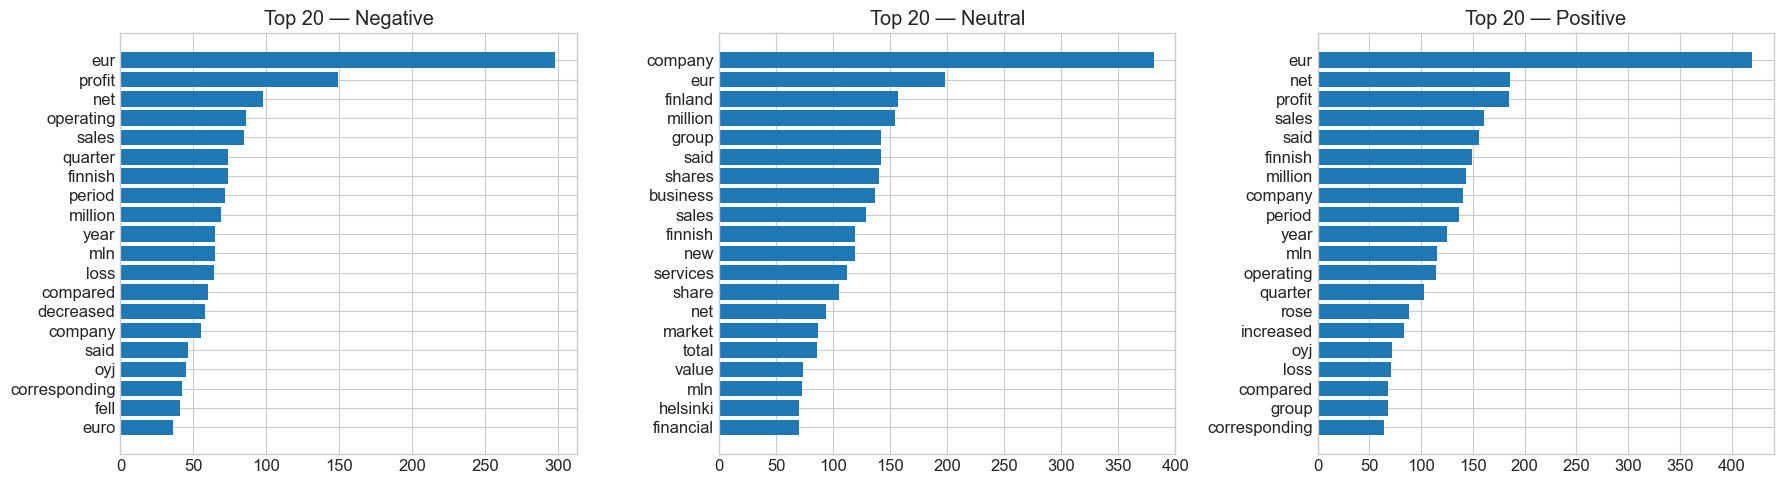

In [8]:
# Palavras mais frequentes por classe
# Isso dá uma intuição sobre quais tokens cada modelo vai aprender a associar com cada sentimento.

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, label in enumerate(['negative', 'neutral', 'positive']):
    words = ' '.join(df[df['label_text'] == label]['sentence']).lower().split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and w.isalpha() and len(w) > 2]
    most_common = Counter(words).most_common(20)
    
    words_list, counts = zip(*most_common)
    axes[idx].barh(range(len(words_list)), counts)
    axes[idx].set_yticks(range(len(words_list)))
    axes[idx].set_yticklabels(words_list)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 20 — {label.capitalize()}')

plt.tight_layout()
plt.show()

In [9]:
# Exemplos de frases por classe — inspeção qualitativa
for label in ['negative', 'neutral', 'positive']:
    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}")
    samples = df[df['label_text'] == label]['sentence'].sample(3, random_state=SEED)
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")


  NEGATIVE
  1. The situation of coated magazine printing paper will continue to be weak .
  2. Alma Media 's operating profit amounted to EUR 11.9 mn , down from EUR 15.0 mn a year earlier .
  3. Reported operating margin was a negative 5.9 % .

  NEUTRAL
  1. Thanks to its extensive industry and operations experience , Cybercom offers strategic and technological expertise to these markets : telecom , industry , media , public sector , retail , and banking and financial services .
  2. The company is reportedly searching for a replacement for CEO Olli-Pekka Kallasvuo .
  3. The device can also be used for theft protection and positioning of vehicles , boats and other assets .

  POSITIVE
  1. Revenue grew 1 percent to euro742 .2 million US$ 964 million from euro735 million .
  2. Luxembourg-registered investment fund Amber Trust II has won the final approval of Lithuania 's Competition Council to acquire 29.6 percent of Sanitas , the country 's largest pharmaceutical producer .
  3. 

### 1.3 Train/Test Split

Stratified split para manter a proporção de classes. Não há dimensão temporal neste dataset (as frases são independentes), então um random split é apropriado.

In [10]:
X = df['sentence'].tolist()
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Proporção no treino: {np.bincount(y_train) / len(y_train)}")
print(f"Proporção no teste:  {np.bincount(y_test) / len(y_test)}")

Train: 2762 | Test: 691
Proporção no treino: [0.12165098 0.62165098 0.25669804]
Proporção no teste:  [0.12156295 0.62083936 0.25759768]


---
## 2. Pré-processamento

Cada abordagem tem seu próprio pipeline de pré-processamento. Essa é uma das lições centrais: a forma como você representa o texto determina o teto do modelo.

| Abordagem | Representação | Dimensão típica | O que captura | O que perde |
|---|---|---|---|---|
| BoW | Contagem de palavras | ~vocabulário (milhares) | Presença de termos | Ordem, semântica, contexto |
| TF-IDF | Frequência ponderada | ~vocabulário (milhares) | Importância relativa | Ordem, semântica, contexto |
| Embeddings | Vetores densos aprendidos | ~100-300 | Similaridade semântica | Contexto de longa distância |
| BERT/FinBERT | Representações contextuais | 768 | Tudo acima + contexto | (Pouco — estado da arte) |

In [11]:
# Pré-processamento para modelos clássicos (BoW e TF-IDF)
# O CountVectorizer e TfidfVectorizer do sklearn já fazem tokenização e lowercase.
# Vamos definir os vetorizadores aqui e usá-los nos respectivos modelos.

bow_vectorizer = CountVectorizer(
    max_features=5000,    # Limitar vocabulário
    stop_words='english',
    ngram_range=(1, 2),   # Unigrams + bigrams (captura "not good", "net profit", etc.)
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      
    ngram_range=(1, 2),
    min_df=2,          
    max_df=0.95,       
)

# Fit nos dados de treino, transform em ambos
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"BoW shape:   {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Esparsidade BoW: {1 - X_train_bow.nnz / np.prod(X_train_bow.shape):.4f}")

BoW shape:   (2762, 5000)
TF-IDF shape: (2762, 9081)
Esparsidade BoW: 0.9973


---
## 3. Modelo 1: BoW + Logistic Regression (Baseline)

O baseline mais simples possível. Logistic Regression sobre contagens de palavras.

**Por que Logistic Regression?** É um modelo linear, interpretável, e robusto. Em alta dimensão e dados esparsos (que é o caso de BoW), modelos lineares frequentemente competem com modelos mais complexos. O regularizador L2 default ajuda com a alta dimensionalidade.

In [12]:
# Treinar
lr_bow = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_bow.fit(X_train_bow, y_train)

# Avaliar
y_pred_lr_bow = lr_bow.predict(X_test_bow)

print("=" * 50)
print("MODELO 1: BoW + Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred_lr_bow, target_names=label_map.values()))

# Cross-validation no treino
cv_scores = cross_val_score(lr_bow, X_train_bow, y_train, cv=5, scoring='f1_macro')
print(f"CV F1-macro: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

MODELO 1: BoW + Logistic Regression
              precision    recall  f1-score   support

    negative       0.70      0.61      0.65        84
     neutral       0.87      0.92      0.89       429
    positive       0.77      0.71      0.74       178

    accuracy                           0.83       691
   macro avg       0.78      0.74      0.76       691
weighted avg       0.82      0.83      0.82       691

CV F1-macro: 0.7469 (± 0.0192)


**precision:** dos elementos que o modelo disse ser dessa classe, quantos realmente eram? Se o modelo presidde 100 frases como "positivo" e 80 eram de fato positiva, precision = 0,8. Essa é uma medida do quanto se pode confiar quando o modelo diz "isso é positivo"

**recall:** de todas as frases que realmente são dessas classes, quantas o moelo acertou? Se existem 90 frases positivas no teste e o modelo encontrou 72, recall = 0,8. Essa é uma medida de o quanto o modelo está "perdendo" exemplos daquela classe

**f1-score:** é a média harmônica de precision e recall. Essa medida é útil porque penaliza desbalanceamento entre os dois. Se precision = 0,95 mas recall = 0,1, a média aritimética daria 0,525, mas f1 dá 0,18 (revela que o modelo está falhando). No caso de classes desbalanceadas, essa é a métrica mais informativa

**support:** quantas amostras de cada classe existem no teste

**macro avg:** média simples das métricas (no caso desse conjunto de dados, que é desbalanceado, macro avg é mais revelador, porque expõe se o modelo está ignorando classes minoritárias)

**weighted avg:** média ponderada pelo support

---
## 4. Modelo 2: TF-IDF + Naive Bayes e Logistic Regression

Agora com ponderação TF-IDF. Vamos testar tanto Naive Bayes quanto Logistic Regression para ver o efeito da representação vs. o efeito do classificador.

**Naive Bayes** assume independência condicional entre features (palavras) dado a classe — a famosa "naive assumption". Em texto, essa assunção é claramente violada ("net" e "profit" coocorrem), mas na prática funciona bem porque o que importa é a decisão de classificação, não a calibração das probabilidades.

In [ ]:
# Regressão logística com TF-IDF 

lr_tfidf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=" * 50)
print("MODELO 2b: TF-IDF + Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred_lr_tfidf, target_names=label_map.values()))

cv_lr_tfidf = cross_val_score(lr_tfidf, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
print(f"CV F1-macro: {cv_lr_tfidf.mean():.4f} (± {cv_lr_tfidf.std():.4f})")

MODELO 2b: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.78      0.70      0.74        84
     neutral       0.89      0.91      0.90       429
    positive       0.77      0.76      0.76       178

    accuracy                           0.85       691
   macro avg       0.81      0.79      0.80       691
weighted avg       0.85      0.85      0.85       691

CV F1-macro: 0.7824 (± 0.0035)


**Discussão:** Comparar BoW+LR vs TF-IDF+LR isola o efeito da representação (mantendo o classificador fixo). Comparar TF-IDF+NB vs TF-IDF+LR isola o efeito do classificador (mantendo a representação fixa). Essa decomposição é mais informativa do que simplesmente comparar resultados finais.

---
## 5. Modelo 3: Rede Neural com Embeddings (PyTorch)

Aqui passamos de representações esparsas para densas. A arquitetura:

1. **Embedding Layer** — Cada palavra é mapeada para um vetor denso de dimensão `d` (aprendido durante o treino)
2. **Global Average Pooling** — Média dos embeddings de todas as palavras da frase → vetor fixo
3. **Camadas Densas** — Classificação com ativação ReLU e dropout
4. **Softmax** — Saída em 3 classes

A intuição: o embedding aprende que "lucro" e "ganho" devem ter vetores similares (porque aparecem em contextos parecidos), algo que BoW/TF-IDF não capturam.

In [ ]:
# Construir vocabulário e tokenizar

# Tokenização simples (split + lowercase)
def tokenize(text):
    return text.lower().split()

# Construir vocabulário a partir do treino
word_counts = Counter()
for text in X_train:
    word_counts.update(tokenize(text))

# Filtrar palavras raras e reindexar sequencialmente
MIN_FREQ = 2
vocab = {'<PAD>': 0, '<UNK>': 1}
idx = 2
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = idx
        idx += 1

VOCAB_SIZE = len(vocab)
print(f"Tamanho do vocabulário: {VOCAB_SIZE}")

# Converter frases em sequências de índices
def encode(text, vocab, max_len=64):
    tokens = tokenize(text)
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens[:max_len]]
    # Padding
    indices += [vocab['<PAD>']] * (max_len - len(indices))
    return indices

MAX_LEN = 64

X_train_encoded = np.array([encode(text, vocab, MAX_LEN) for text in X_train])
X_test_encoded = np.array([encode(text, vocab, MAX_LEN) for text in X_test])

print(f"Shape encoded: {X_train_encoded.shape}")
print(f"Exemplo: '{X_train[0][:80]}...'")
print(f"Encoded: {X_train_encoded[0][:15]}...")

Tamanho do vocabulário: 3598
Shape encoded: (2762, 64)
Exemplo: 'The official opening of the office , located in Prague , will be celebrated on M...'
Encoded: [ 2  3  4  5  2  6  7  8  9  1  7 10 11  1 12]...


In [ ]:
# Dataset e DataLoader

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = SentimentDataset(X_train_encoded, y_train)
test_dataset = SentimentDataset(X_test_encoded, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Definição da rede neural

class SentimentNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1 = nn.Linear(embed_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4) # antes de 0.3
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)
        
        # Global average pooling — ignorar padding
        mask = (x != 0).unsqueeze(-1).float()     
        embedded = embedded * mask                 
        pooled = embedded.sum(dim=1) / mask.sum(dim=1).clamp(min=1)  
        
        out = self.dropout(self.relu(self.fc1(pooled)))
        out = self.fc2(out)
        return out

EMBED_DIM = 64 #antes era 128
NUM_CLASSES = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentNN(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal de parâmetros: {total_params:,}")

SentimentNN(
  (embedding): Embedding(3598, 64, padding_idx=0)
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Total de parâmetros: 238,979


In [17]:
print(f"VOCAB_SIZE: {VOCAB_SIZE}")
print(f"Max index treino: {np.max(X_train_encoded)}")
print(f"Max index teste: {np.max(X_test_encoded)}")

VOCAB_SIZE: 3598
Max index treino: 3597
Max index teste: 3595


In [ ]:
# Treinamendo

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 30
history = {'train_loss': [], 'train_f1': [], 'test_f1': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
    
    # Avaliar no teste
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            test_preds.extend(outputs.argmax(dim=1).cpu().numpy())
    
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    test_f1 = f1_score(y_test, test_preds, average='macro')
    avg_loss = total_loss / len(train_loader)
    
    history['train_loss'].append(avg_loss)
    history['train_f1'].append(train_f1)
    history['test_f1'].append(test_f1)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

Epoch 05/30 | Loss: 0.5289 | Train F1: 0.6441 | Test F1: 0.6385
Epoch 10/30 | Loss: 0.2477 | Train F1: 0.8780 | Test F1: 0.7099
Epoch 15/30 | Loss: 0.1026 | Train F1: 0.9535 | Test F1: 0.7304
Epoch 20/30 | Loss: 0.0436 | Train F1: 0.9848 | Test F1: 0.7402
Epoch 25/30 | Loss: 0.0204 | Train F1: 0.9917 | Test F1: 0.7441
Epoch 30/30 | Loss: 0.0101 | Train F1: 0.9958 | Test F1: 0.7477


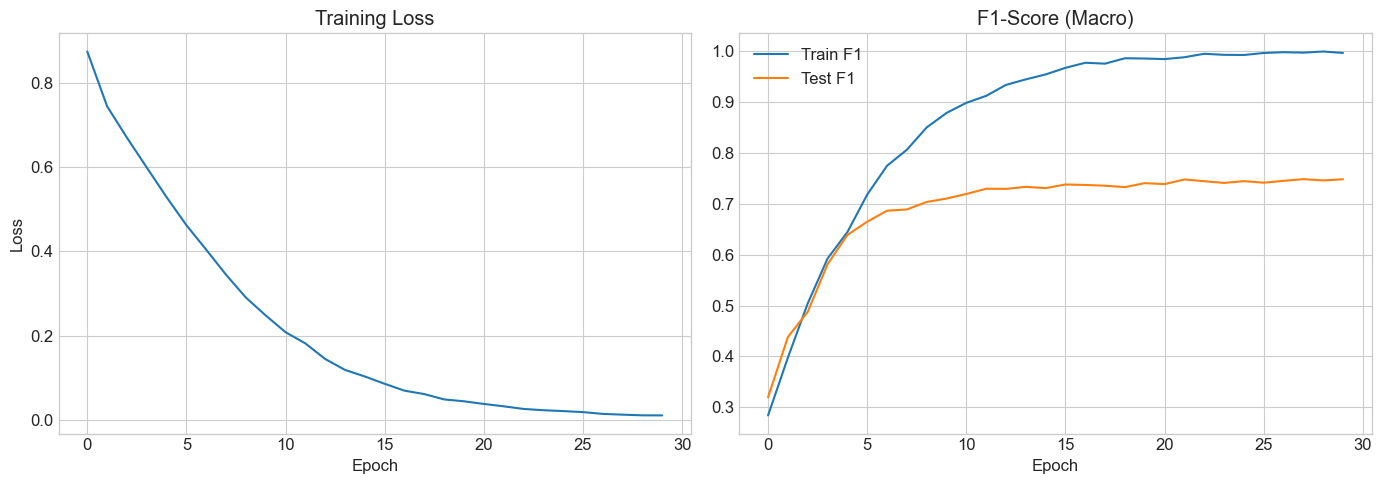

In [ ]:
# Training loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['test_f1'], label='Test F1')
axes[1].set_title('F1-Score (Macro)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Resultados da rede neural no conjunto de teste

model.eval()
y_pred_nn = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        y_pred_nn.extend(outputs.argmax(dim=1).cpu().numpy())

y_pred_nn = np.array(y_pred_nn)

print("=" * 50)
print("MODELO 3: Rede Neural com Embeddings")
print("=" * 50)
print(classification_report(y_test, y_pred_nn, target_names=label_map.values()))

MODELO 3: Rede Neural com Embeddings
              precision    recall  f1-score   support

    negative       0.65      0.62      0.63        84
     neutral       0.88      0.90      0.89       429
    positive       0.74      0.70      0.72       178

    accuracy                           0.82       691
   macro avg       0.76      0.74      0.75       691
weighted avg       0.81      0.82      0.81       691



---
## 6. Modelo 4: FinBERT (Transformer pré-treinado)

FinBERT é um BERT fine-tuned em texto financeiro. Aqui usamos o modelo pré-treinado diretamente via `pipeline` do Hugging Face — sem fine-tuning adicional.

**Por que isso já funciona bem?** O pré-treino em corpus financeiro ensinou ao modelo a semântica do domínio. O fine-tuning para sentiment analysis já foi feito pelos autores. Estamos apenas usando o modelo como está.

Isso também ilustra o paradigma moderno de NLP: **pre-train → fine-tune → deploy**, em contraste com o treino do zero dos modelos anteriores.

In [ ]:
# Carregar FinBERT
# NOTA: Na primeira execução, o modelo (~400MB) será baixado

finbert = hf_pipeline(
    'sentiment-analysis',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1
)

print("FinBERT carregado com sucesso.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 43355.88it/s]


FinBERT carregado com sucesso.


In [ ]:
# Inferência no conjunto de teste

finbert_label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

# Processar em batches para eficiência
finbert_results = finbert(list(X_test), batch_size=32)

y_pred_finbert = np.array([finbert_label_map[r['label']] for r in finbert_results])

print("=" * 50)
print("MODELO 4: FinBERT (pré-treinado)")
print("=" * 50)
print(classification_report(y_test, y_pred_finbert, target_names=label_map.values()))

MODELO 4: FinBERT (pré-treinado)
              precision    recall  f1-score   support

    negative       0.89      0.98      0.93        84
     neutral       1.00      0.95      0.97       429
    positive       0.90      0.97      0.93       178

    accuracy                           0.96       691
   macro avg       0.93      0.96      0.94       691
weighted avg       0.96      0.96      0.96       691



---
## 7. Comparação Final e Análise de Erros

In [ ]:
# Tabela de comparação entre os modelos

results = {}
predictions = {
    'BoW + LogReg': y_pred_lr_bow,
    'TF-IDF + LogReg': y_pred_lr_tfidf,
    'Neural (Embeddings)': y_pred_nn,
    'FinBERT': y_pred_finbert,
}

for name, y_pred in predictions.items():
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'F1-Negative': f1_score(y_test, y_pred, average=None)[0],
        'F1-Neutral': f1_score(y_test, y_pred, average=None)[1],
        'F1-Positive': f1_score(y_test, y_pred, average=None)[2],
    }

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df = results_df.sort_values('F1-Macro', ascending=False)
print(results_df.to_string())

                     Accuracy  F1-Macro  F1-Negative  F1-Neutral  F1-Positive
FinBERT                0.9551    0.9447       0.9318      0.9701       0.9322
TF-IDF + LogReg        0.8480    0.8015       0.7375      0.9022       0.7649
BoW + LogReg           0.8263    0.7600       0.6497      0.8914       0.7390
Neural (Embeddings)    0.8162    0.7477       0.6341      0.8886       0.7205


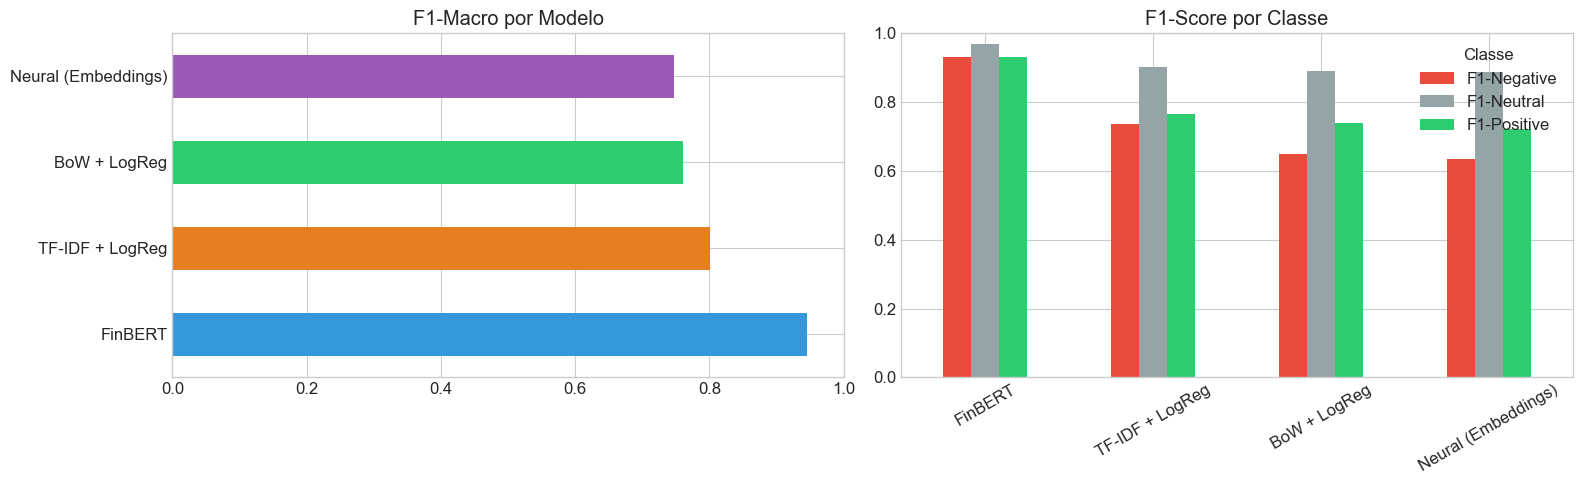

In [ ]:
# Gráficos de comparação entre os modelos

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-Macro por modelo
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']
results_df['F1-Macro'].plot(kind='barh', ax=axes[0], color=colors[:len(results_df)])
axes[0].set_title('F1-Macro por Modelo')
axes[0].set_xlim(0, 1)

# F1 por classe por modelo
results_df[['F1-Negative', 'F1-Neutral', 'F1-Positive']].plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#95a5a6', '#2ecc71']
)
axes[1].set_title('F1-Score por Classe')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Classe')

plt.tight_layout()
plt.show()

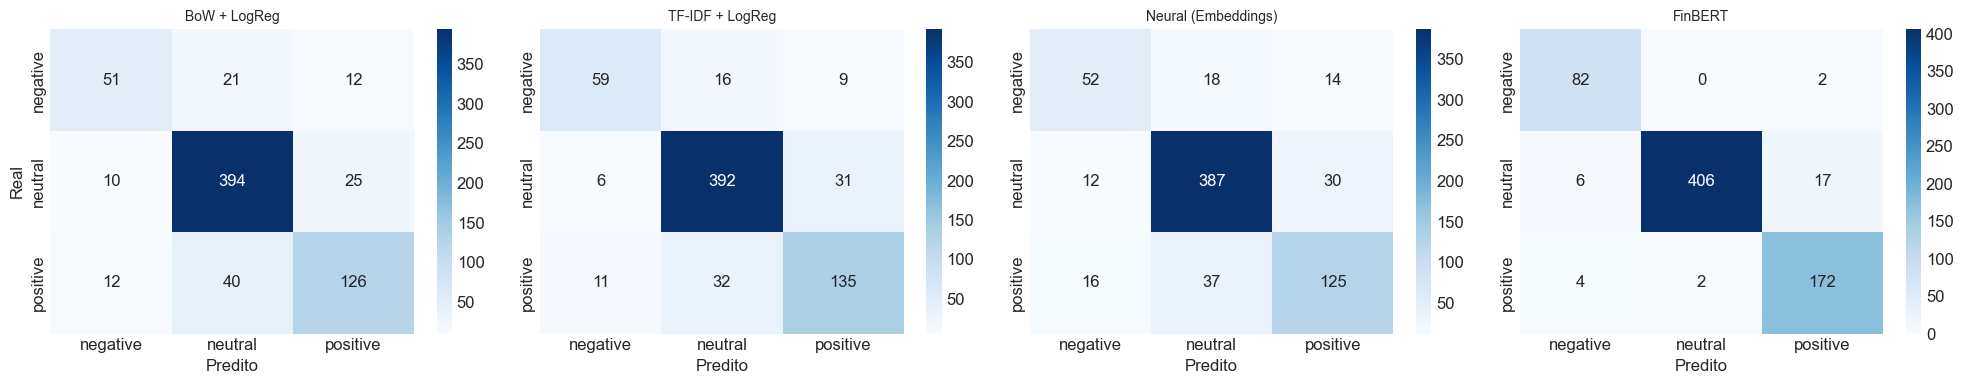

In [ ]:
# Matriz de confusão

fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=label_map.values(), yticklabels=label_map.values()
    )
    axes[idx].set_title(name, fontsize=10)
    axes[idx].set_ylabel('Real' if idx == 0 else '')
    axes[idx].set_xlabel('Predito')

plt.tight_layout()
plt.show()

### 7.1 Análise de Erros — Onde os modelos erram?

In [ ]:
# Frases que TODOS os modelos erram

all_wrong = np.ones(len(y_test), dtype=bool)
for y_pred in predictions.values():
    all_wrong &= (y_pred != y_test)

print(f"Frases que TODOS os modelos erraram: {all_wrong.sum()} / {len(y_test)}\n")

indices = np.where(all_wrong)[0][:10]
for i in indices:
    print(f"  Frase: {X_test[i][:120]}")
    print(f"  Real: {label_map[y_test[i]]} | Predições: ", end='')
    print(' | '.join([f"{name}: {label_map[y_pred[i]]}" for name, y_pred in predictions.items()]))
    print()

Frases que TODOS os modelos erraram: 7 / 691

  Frase: Electricity consumption grows with higher frequencies .
  Real: neutral | Predições: BoW + LogReg: positive | TF-IDF + LogReg: positive | Neural (Embeddings): positive | FinBERT: positive

  Frase: Among other industrial stocks , Metso added 0.53 pct to 40.04 eur , Wartsila B was down 0.77 pct at 47.87 eur and Rautar
  Real: neutral | Predições: BoW + LogReg: negative | TF-IDF + LogReg: negative | Neural (Embeddings): negative | FinBERT: negative

  Frase: It 's even a little bit higher than Yara 's multiples on itself , ' an analyst in Helsinki said .
  Real: neutral | Predições: BoW + LogReg: positive | TF-IDF + LogReg: positive | Neural (Embeddings): positive | FinBERT: positive

  Frase: Unit costs for flight operations fell by 6.4 percent .
  Real: positive | Predições: BoW + LogReg: negative | TF-IDF + LogReg: negative | Neural (Embeddings): negative | FinBERT: negative

  Frase: Fiskars has a strong portfolio of internationa

---
## 8. Conclusões